# Component profiling — where does docking time go?

Breaks down a single `step()` call into:
- **RDKit**: `transform()`, `set_dihedral_angles()`, conformer management
- **Scipy**: KDTree query (`KNNDependency.compute`)
- **NumPy helpers**: `_rotation_matrix_from_euler`, `_translation_matrix_from_coordinates`
- **NumPy kernels**: Gaussian, Repulsion, Hydrophobic, NonDirHBond, PlantsPLP, InternalOverlap

All timings use `timeit.repeat` with N=2000 repetitions and report the median.

In [1]:
import sys
sys.path.insert(0, '/Users/martvanderlugt/Dev/Pyrite')

import timeit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyrite._common import (
    Mol, _rotation_matrix_from_euler, _translation_matrix_from_coordinates
)
from pyrite.scoring import (
    Gaussian, Repulsion, Hydrophobic, NonDirHBond, NonDirHBondLJ,
    InternalOverlap, InternalEnergy, PlantsPLP, NumTors, DistanceToPocket,
)
from pyrite.bounds import Pocket, RectangularBounds

sns.set_theme(style='ticks')
N = 2000  # repetitions per timing

def bench(fn, n=N):
    """Median time in microseconds over n calls."""
    return np.median(timeit.repeat(fn, number=1, repeat=n)) * 1e6

In [2]:
PROT = '1mmv'
BASE = '/Users/martvanderlugt/Dev/bp/input/astex'

receptor = Mol.from_pdb(f'{BASE}/{PROT}/{PROT}_protein-processed.pdb')
ligand   = Mol.from_sdf(f'{BASE}/{PROT}/{PROT}_ligand.sdf', flexible=True)

print(f'Ligand heavy atoms : {ligand.GetNumHeavyAtoms()}')
print(f'Ligand dihedrals   : {len(ligand.dihedral_angles)}')
print(f'Receptor atoms     : {receptor.GetNumAtoms()}')

# Reference variables at crystal pose
ref_vars = np.zeros(6 + len(ligand.dihedral_angles))
ref_vars[3:6] = ligand.position
ref_vars[6:]  = ligand.dihedral_angles

Ligand heavy atoms : 15
Ligand dihedrals   : 9
Receptor atoms     : 6542


In [3]:
k = 400

sf_gauss_s  = Gaussian(ligand, receptor, offset=0.0, width=0.5, k=k)
sf_gauss_b  = Gaussian(ligand, receptor, offset=3.0, width=2.0, k=k)
sf_rep      = Repulsion(ligand, receptor, offset=0.0, k=k)
sf_hydro    = Hydrophobic(ligand, receptor, good=0.5, bad=1.5, k=k)
sf_hbond    = NonDirHBond(ligand, receptor, good=-0.7, bad=0.0, k=k)
sf_hbond_lj = NonDirHBondLJ(ligand, receptor, k=k)
sf_plp      = PlantsPLP(ligand, receptor, k=k)
sf_int_ov   = InternalOverlap(ligand)
sf_int_en   = InternalEnergy(ligand)

pocket  = Pocket.from_mol(receptor, gt_distance_to_outside=14)
sf_dtp  = DistanceToPocket(ligand, pocket)

sf_num_tors = NumTors(ligand)

vina_sf = (
    -0.035579 * sf_gauss_s
    + -0.005156 * sf_gauss_b
    + 0.840245  * sf_rep
    + -0.035069 * sf_hydro
    + -0.587439 * sf_hbond
) / (1 + ((0.1 * (1.923 + 1)) * sf_num_tors) / 5)

print('Scoring functions built.')

Scoring functions built.


## 1  NumPy helpers (no RDKit, no KDTree)

In [4]:
t_euler = bench(lambda: _rotation_matrix_from_euler(0.3, 0.5, 1.2))
t_trans = bench(lambda: _translation_matrix_from_coordinates(1.0, 2.0, 3.0))

print(f'_rotation_matrix_from_euler          {t_euler:8.2f} µs')
print(f'_translation_matrix_from_coordinates {t_trans:8.2f} µs')

_rotation_matrix_from_euler              3.54 µs
_translation_matrix_from_coordinates     1.04 µs


## 2  RDKit operations

In [5]:
# transform() = build rotation/translation matrices + RDKit TransformConformer
t_transform = bench(lambda: ligand.transform(0.3, 0.5, 1.2, 1.0, 2.0, 3.0))

# set_dihedral_angles()
n_dihed = len(ligand.dihedral_angles)
test_angles = np.zeros(n_dihed)
t_dihed = bench(lambda: ligand.set_dihedral_angles(test_angles)) if n_dihed > 0 else 0.0

# AddConformer + RemoveConformer (per-step overhead)
def _add_remove():
    cid = ligand.AddConformer(ligand.GetConformer(), assignId=True)
    ligand.RemoveConformer(cid)
t_add_conf = bench(_add_remove)

# Full update() — the call the optimizer makes every step
def _update():
    cid = ligand.update(ref_vars, new_conf=True)
    ligand.RemoveConformer(cid)
t_update = bench(_update)

print(f'transform()              {t_transform:8.2f} µs')
print(f'set_dihedral_angles()    {t_dihed:8.2f} µs  (n={n_dihed})')
print(f'AddConformer+Remove      {t_add_conf:8.2f} µs')
print(f'update() full            {t_update:8.2f} µs')

transform()                  9.75 µs
set_dihedral_angles()       12.13 µs  (n=9)
AddConformer+Remove          0.71 µs
update() full               24.40 µs


## 3  Scipy KDTree query

In [6]:
# Protein scoring functions all share one KNNDependency
nn_dep = sf_gauss_s.nn_dep
t_kdtree = bench(lambda: nn_dep.compute(-1))

# DistanceToPocket has its own KDTree (k=1 query against pocket grid)
t_kdtree_pocket = bench(lambda: sf_dtp._nn_dep.compute(-1))

print(f'KDTree  k={k}  (protein SFs shared) {t_kdtree:8.2f} µs')
print(f'KDTree  k=1   (pocket)              {t_kdtree_pocket:8.2f} µs')

KDTree  k=400  (protein SFs shared)    98.83 µs
KDTree  k=1   (pocket)                 35.67 µs


## 4  Scoring kernels (NumPy only — pre-computed KDTree)

In [7]:
# Pre-compute once so we time only the numpy math
computed_knn = {nn_dep: nn_dep.compute(-1)}
computed_dtp = {sf_dtp._nn_dep: sf_dtp._nn_dep.compute(-1)}

def time_kern(sf, computed):
    return bench(lambda: sf._score(-1, computed))

t_gauss_s  = time_kern(sf_gauss_s,  computed_knn)
t_gauss_b  = time_kern(sf_gauss_b,  computed_knn)
t_rep      = time_kern(sf_rep,      computed_knn)
t_hydro    = time_kern(sf_hydro,    computed_knn)
t_hbond    = time_kern(sf_hbond,    computed_knn)
t_hbond_lj = time_kern(sf_hbond_lj, computed_knn)
t_plp      = time_kern(sf_plp,      computed_knn)
t_dtp      = time_kern(sf_dtp,      computed_dtp)
t_int_ov   = bench(lambda: sf_int_ov._score(-1, {}))   # uses RDKit Get3DDistanceMatrix internally
t_int_en   = bench(lambda: sf_int_en._score(-1, {}))   # MMFF forcefield via RDKit

kernel_data = [
    ('Gaussian (small)',  t_gauss_s),
    ('Gaussian (big)',    t_gauss_b),
    ('Repulsion',         t_rep),
    ('Hydrophobic',       t_hydro),
    ('NonDirHBond',       t_hbond),
    ('NonDirHBondLJ',     t_hbond_lj),
    ('PlantsPLP',         t_plp),
    ('DistanceToPocket',  t_dtp),
    ('InternalOverlap*',  t_int_ov),
    ('InternalEnergy*',   t_int_en),
]
print('* includes internal RDKit call, not pure numpy\n')
for name, t in kernel_data:
    print(f'  {name:22s}  {t:8.2f} µs')

* includes internal RDKit call, not pure numpy

  Gaussian (small)           51.85 µs
  Gaussian (big)             52.00 µs
  Repulsion                  41.75 µs
  Hydrophobic                69.00 µs
  NonDirHBond                91.83 µs
  NonDirHBondLJ             198.83 µs
  PlantsPLP                 146.08 µs
  DistanceToPocket            2.83 µs
  InternalOverlap*            5.92 µs
  InternalEnergy*            16.62 µs


## 5  Full `get_score()` = KDTree + kernel

In [8]:
t_gs_full   = bench(lambda: sf_gauss_s.get_score())
t_rep_full  = bench(lambda: sf_rep.get_score())
t_plp_full  = bench(lambda: sf_plp.get_score())
t_dtp_full  = bench(lambda: sf_dtp.get_score())
t_vina_full = bench(lambda: vina_sf.get_score())  # 5 kernels, 1 shared KDTree

print('get_score() breakdown (total vs. KDTree vs. kernel):')
for name, t_full, t_kern, t_tree in [
    ('Gaussian(small)',  t_gs_full,   t_gauss_s, t_kdtree),
    ('Repulsion',        t_rep_full,  t_rep,     t_kdtree),
    ('PlantsPLP',        t_plp_full,  t_plp,     t_kdtree),
    ('DistanceToPocket', t_dtp_full,  t_dtp,     t_kdtree_pocket),
    ('Vina (5 terms)',   t_vina_full, t_gauss_s+t_gauss_b+t_rep+t_hydro+t_hbond, t_kdtree),
]:
    overhead = max(0, t_full - t_kern - t_tree)
    print(f'  {name:20s}  total={t_full:6.1f}µs  kdtree={t_tree:5.1f}  kernel={t_kern:5.1f}  overhead={overhead:5.1f}')

get_score() breakdown (total vs. KDTree vs. kernel):
  Gaussian(small)       total= 220.2µs  kdtree= 98.8  kernel= 51.9  overhead= 69.5
  Repulsion             total= 205.1µs  kdtree= 98.8  kernel= 41.7  overhead= 64.5
  PlantsPLP             total= 306.4µs  kdtree= 98.8  kernel=146.1  overhead= 61.4
  DistanceToPocket      total=  86.5µs  kdtree= 35.7  kernel=  2.8  overhead= 48.0
  Vina (5 terms)        total= 475.4µs  kdtree= 98.8  kernel=306.4  overhead= 70.1


## 6  Full Vina `step()` breakdown

In [9]:
t_vina_step = bench(lambda: vina_sf.step(ref_vars, ligand))

vina_kernels = t_gauss_s + t_gauss_b + t_rep + t_hydro + t_hbond
t_other = max(0, t_vina_step - t_update - t_kdtree - vina_kernels)

print(f'Vina step() total:  {t_vina_step:.1f} µs\n')
print(f'  update()  (RDKit)          {t_update:8.2f} µs  ({t_update/t_vina_step*100:5.1f}%)')
print(f'  KDTree    (scipy, k={k})  {t_kdtree:8.2f} µs  ({t_kdtree/t_vina_step*100:5.1f}%)')
print(f'  Kernels   (numpy, 5 terms) {vina_kernels:8.2f} µs  ({vina_kernels/t_vina_step*100:5.1f}%)')
print(f'  Python overhead            {t_other:8.2f} µs  ({t_other/t_vina_step*100:5.1f}%)')

Vina step() total:  516.6 µs

  update()  (RDKit)             24.40 µs  (  4.7%)
  KDTree    (scipy, k=400)     98.83 µs  ( 19.1%)
  Kernels   (numpy, 5 terms)   306.44 µs  ( 59.3%)
  Python overhead               86.92 µs  ( 16.8%)


## 7  Summary chart

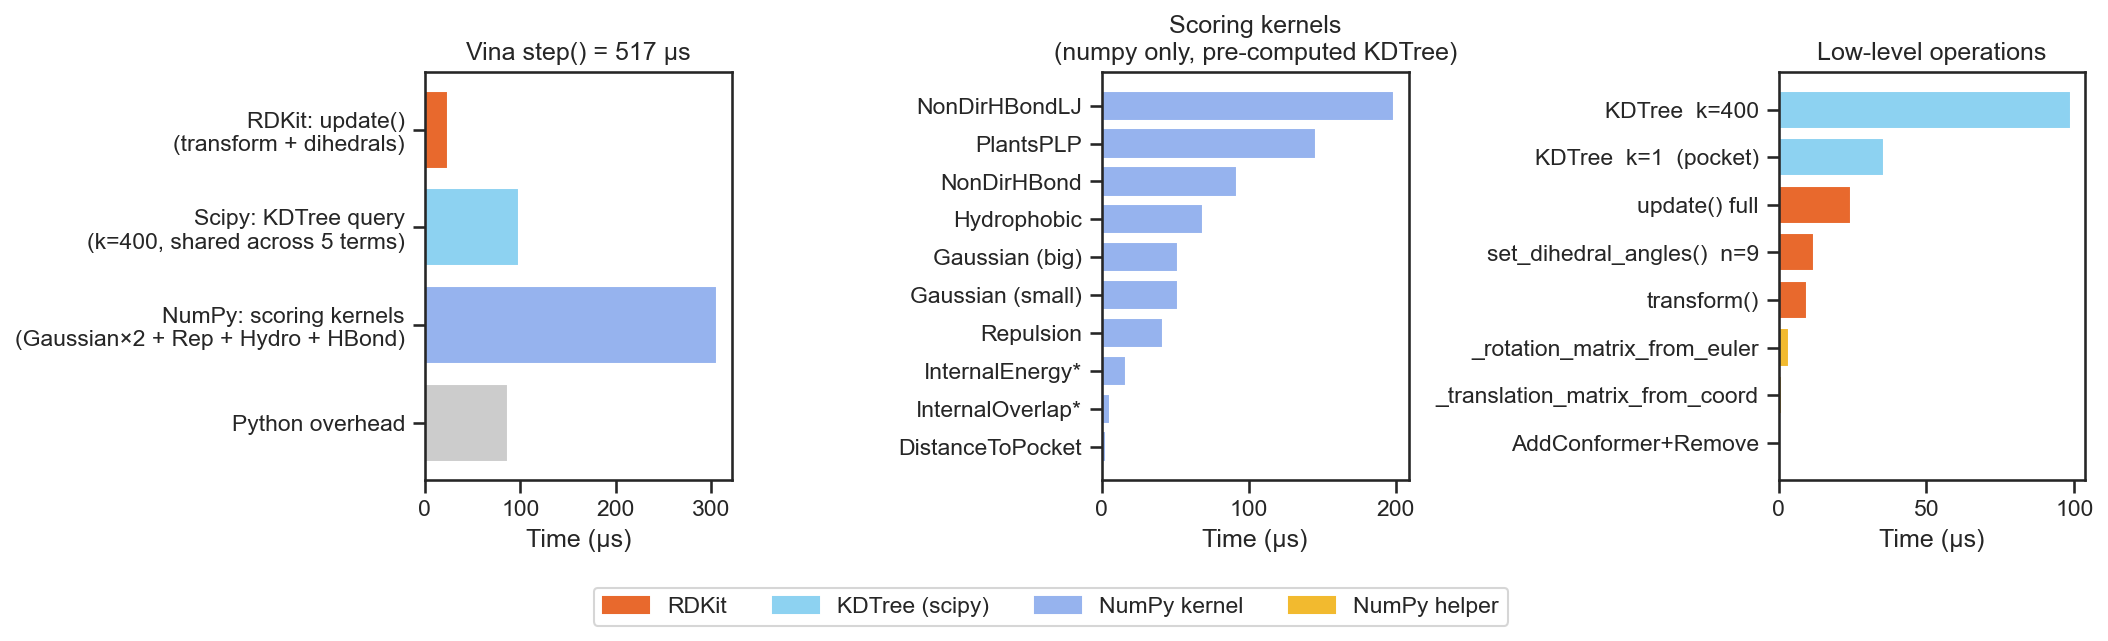

In [10]:
cm = 1/2.54
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm), dpi=150)

# Panel 1 — Vina step() breakdown
step_labels = [
    f'RDKit: update()\n(transform + dihedrals)',
    f'Scipy: KDTree query\n(k={k}, shared across 5 terms)',
    'NumPy: scoring kernels\n(Gaussian×2 + Rep + Hydro + HBond)',
    'Python overhead',
]
step_values = [t_update, t_kdtree, vina_kernels, t_other]
step_colors = ['#e8692d', '#8DD2F1', '#96B3EE', '#cccccc']
axes[0].barh(step_labels, step_values, color=step_colors)
axes[0].set_xlabel('Time (µs)')
axes[0].set_title(f'Vina step() = {t_vina_step:.0f} µs')
axes[0].invert_yaxis()

# Panel 2 — kernel timings
kdf = pd.DataFrame(kernel_data, columns=['SF', 't']).sort_values('t', ascending=True)
axes[1].barh(kdf['SF'], kdf['t'], color='#96B3EE')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('Scoring kernels\n(numpy only, pre-computed KDTree)')

# Panel 3 — low-level operations
ops = pd.DataFrame([
    ('_rotation_matrix_from_euler',         t_euler,        '#f2ba2f'),
    ('_translation_matrix_from_coord',      t_trans,        '#f2ba2f'),
    ('AddConformer+Remove',                 t_add_conf,     '#e8692d'),
    ('transform()',                         t_transform,    '#e8692d'),
    (f'set_dihedral_angles()  n={n_dihed}', t_dihed,        '#e8692d'),
    ('update() full',                       t_update,       '#e8692d'),
    (f'KDTree  k={k}',                      t_kdtree,       '#8DD2F1'),
    ('KDTree  k=1  (pocket)',               t_kdtree_pocket,'#8DD2F1'),
], columns=['op', 't', 'color']).sort_values('t', ascending=True)
axes[2].barh(ops['op'], ops['t'], color=ops['color'].tolist())
axes[2].set_xlabel('Time (µs)')
axes[2].set_title('Low-level operations')

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(color='#e8692d', label='RDKit'),
        Patch(color='#8DD2F1', label='KDTree (scipy)'),
        Patch(color='#96B3EE', label='NumPy kernel'),
        Patch(color='#f2ba2f', label='NumPy helper'),
    ],
    loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.10),
)
plt.tight_layout()
plt.savefig('profile_components.svg', bbox_inches='tight')
plt.show()

## 8  Sensitivity: how does ligand/receptor size affect timing? (all Astex complexes)

In [11]:
import os

ASTEX_DIR = '/Users/martvanderlugt/Dev/bp/input/astex'
prots = sorted(f.name for f in os.scandir(ASTEX_DIR) if f.is_dir())

records = []
N_QUICK = 200

for prot in prots:
    rec_f = f'{ASTEX_DIR}/{prot}/{prot}_protein-processed.pdb'
    lig_f = f'{ASTEX_DIR}/{prot}/{prot}_ligand.sdf'
    if not (os.path.exists(rec_f) and os.path.exists(lig_f)):
        continue
    try:
        rec = Mol.from_pdb(rec_f)
        lig = Mol.from_sdf(lig_f, flexible=True)
    except Exception as e:
        print(f'{prot}: load failed ({e})')
        continue

    n_d = len(lig.dihedral_angles)
    rv = np.zeros(6 + n_d)
    rv[3:6] = lig.position
    rv[6:]  = lig.dihedral_angles

    sf_g  = Gaussian(lig, rec, offset=0.0, width=0.5, k=400)
    sf_gb = Gaussian(lig, rec, offset=3.0, width=2.0, k=400)
    sf_r  = Repulsion(lig, rec, k=400)
    sf_h  = Hydrophobic(lig, rec, k=400)
    sf_hb = NonDirHBond(lig, rec, k=400)
    sf_nt = NumTors(lig)
    vina  = (
        -0.035579 * sf_g + -0.005156 * sf_gb
        + 0.840245 * sf_r + -0.035069 * sf_h
        + -0.587439 * sf_hb
    ) / (1 + ((0.1 * (1.923 + 1)) * sf_nt) / 5)

    t_step = bench(lambda: vina.step(rv, lig), n=N_QUICK)

    def _upd():
        cid = lig.update(rv, new_conf=True)
        lig.RemoveConformer(cid)
    t_upd  = bench(_upd, n=N_QUICK)
    t_tree = bench(lambda: sf_g.nn_dep.compute(-1), n=N_QUICK)
    precomp = {sf_g.nn_dep: sf_g.nn_dep.compute(-1)}
    t_kern = bench(lambda: (
        sf_g._score(-1, precomp) + sf_gb._score(-1, precomp)
        + sf_r._score(-1, precomp) + sf_h._score(-1, precomp)
        + sf_hb._score(-1, precomp)
    ), n=N_QUICK)

    records.append({
        'prot':        prot,
        'n_heavy':     lig.GetNumHeavyAtoms(),
        'n_dihed':     n_d,
        'n_rec_atoms': rec.GetNumAtoms(),
        't_step':      t_step,
        't_update':    t_upd,
        't_kdtree':    t_tree,
        't_kernels':   t_kern,
    })
    print(f'{prot}  step={t_step:.0f}µs  upd={t_upd:.0f}  tree={t_tree:.0f}  kern={t_kern:.0f}')

df = pd.DataFrame(records)
df.to_csv('profile_astex.csv', index=False)
print(f'\nDone. {len(df)}/{len(prots)} proteins timed.')
df.describe()

1g9v  step=497µs  upd=27  tree=101  kern=343


[21:03:31] WARNING: not removing hydrogen atom without neighbors
[21:03:31] WARNING: not removing hydrogen atom without neighbors


1gkc  step=520µs  upd=29  tree=119  kern=301
1gm8  step=682µs  upd=21  tree=132  kern=415


[21:03:36] Explicit valence for atom # 322 C, 5, is greater than permitted
[21:03:37] Explicit valence for atom # 2035 O, 3, is greater than permitted


1gpk: load failed (Explicit valence for atom # 322 C, 5, is greater than permitted)
1hnn: load failed (Explicit valence for atom # 2035 O, 3, is greater than permitted)
1hp0  step=525µs  upd=16  tree=120  kern=311
1hq2  step=378µs  upd=14  tree=90  kern=228
1hvy  step=791µs  upd=33  tree=181  kern=430
1hwi  step=635µs  upd=29  tree=111  kern=492
1hww  step=709µs  upd=13  tree=88  kern=461
1ia1: load failed (Explicit valence for atom # 835 O, 3, is greater than permitted)


...

1yv3: load failed (Explicit valence for atom # 360 O, 3, is greater than permitted)
1yvf  step=859µs  upd=30  tree=196  kern=489
1ywr  step=878µs  upd=27  tree=298  kern=474
1z95  step=819µs  upd=28  tree=234  kern=431
2bm2: load failed (Explicit valence for atom # 279 C, 5, is greater than permitted)


[21:06:02] Explicit valence for atom # 279 C, 5, is greater than permitted


2br1  step=963µs  upd=23  tree=185  kern=411
2bsm: load failed (Explicit valence for atom # 1642 C, 5, is greater than permitted)

Done. 62/85 proteins timed.


[21:06:05] Explicit valence for atom # 1642 C, 5, is greater than permitted


,n_heavy,n_dihed,n_rec_atoms,t_step,t_update,t_kdtree,t_kernels
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,22.967742,5.387097,5181.806452,668.394839,22.698282,162.067903,386.102508
std,7.319338,2.988255,2358.511609,173.575926,6.531813,67.689399,82.416560
min,10.000000,0.000000,1564.000000,369.770500,12.834000,74.541000,216.333001
25%,17.250000,3.000000,3929.250000,534.697750,17.562751,109.536624,325.291875
50%,23.000000,5.000000,4662.000000,648.708500,21.562251,149.447501,392.968751
75%,28.750000,7.750000,5752.250000,759.114625,26.552002,191.598999,435.104251
max,41.000000,12.000000,16157.000000,1355.395500,43.270500,359.624999,613.729499


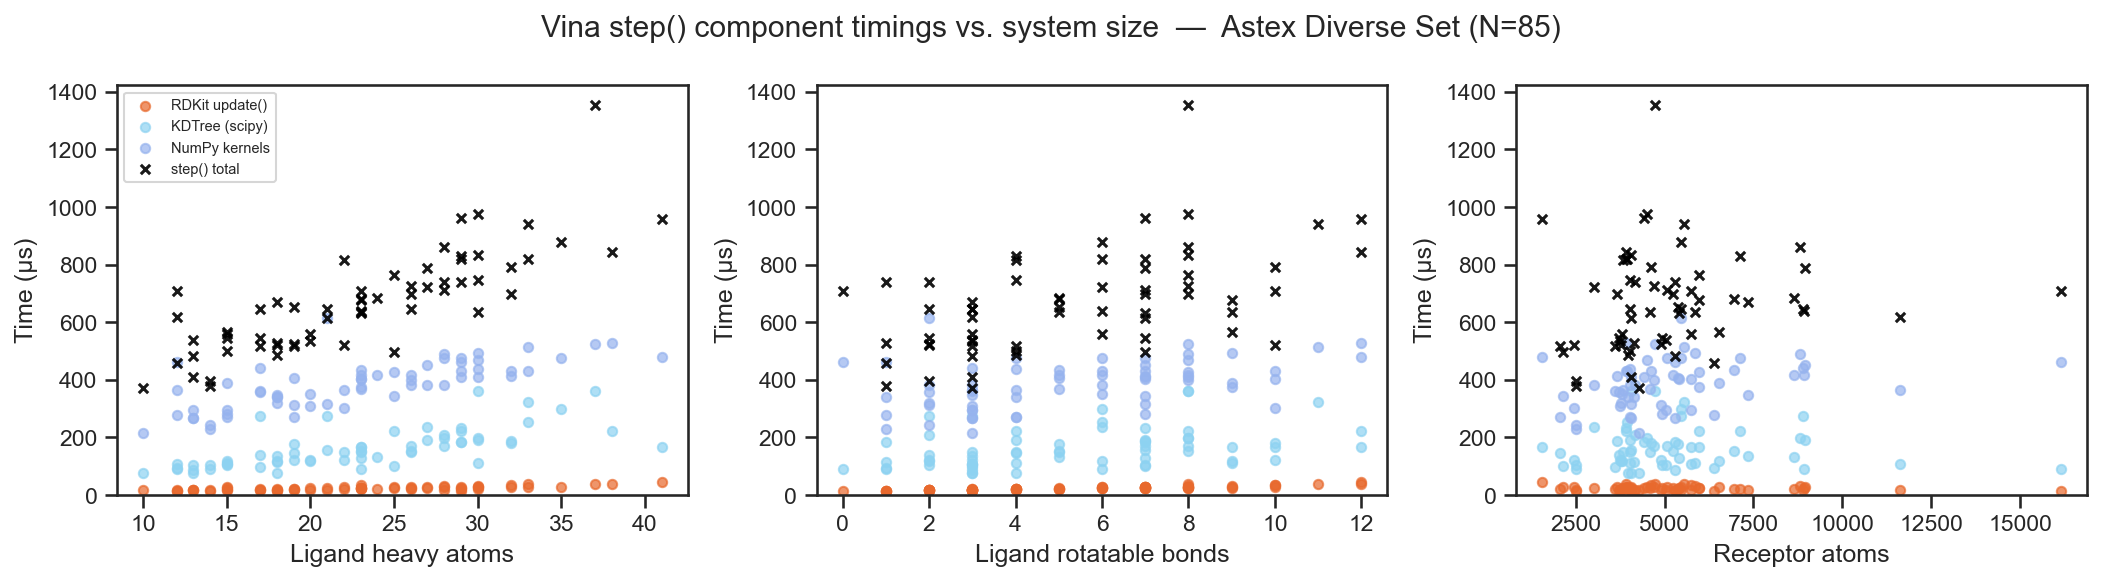

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm), dpi=150)

for ax, xcol, xlabel in [
    (axes[0], 'n_heavy',     'Ligand heavy atoms'),
    (axes[1], 'n_dihed',     'Ligand rotatable bonds'),
    (axes[2], 'n_rec_atoms', 'Receptor atoms'),
]:
    ax.scatter(df[xcol], df['t_update'],  label='RDKit update()',  alpha=0.7, color='#e8692d', s=20)
    ax.scatter(df[xcol], df['t_kdtree'],  label='KDTree (scipy)',  alpha=0.7, color='#8DD2F1', s=20)
    ax.scatter(df[xcol], df['t_kernels'], label='NumPy kernels',   alpha=0.7, color='#96B3EE', s=20)
    ax.scatter(df[xcol], df['t_step'],    label='step() total',    alpha=0.9, color='black',   s=20, marker='x')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Time (µs)')
    ax.set_ylim(bottom=0)

axes[0].legend(fontsize=7)
plt.suptitle('Vina step() component timings vs. system size  —  Astex Diverse Set (N=85)')
plt.tight_layout()
plt.savefig('profile_astex_scatter.svg', bbox_inches='tight')
plt.show()